In [3]:
from io import IncrementalNewlineDecoder
from sentence_transformers import SentenceTransformer
from PIL import Image
import matplotlib.pyplot as plt

import numpy as np
%matplotlib inline

model = SentenceTransformer('clip-ViT-B-32')

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

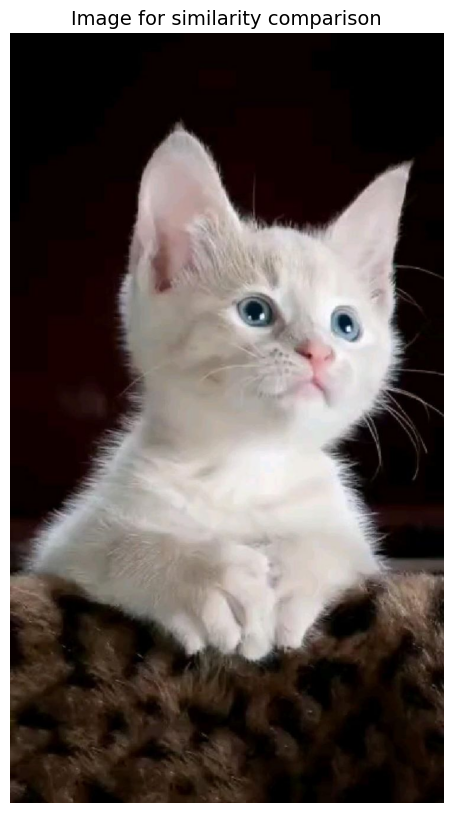

In [4]:
img1 ="/content/image1.jpeg"
img1 = Image.open(img1)
plt.figure(figsize=(10,10))
plt.imshow(img1)
plt.axis("off")
plt.title("Image for similarity comparison" , fontsize=14)

plt.show()

In [ ]:
text_description = ["Two Dogs in the Snow" ,
                    " A Cat on the Table " ,
                    " A picture of London at night" ,
                    " A Dog sleeping on the couch" ,
                    " Two cats are fighting in the garden"]

In [40]:
def display_image_and_compare(image_path , text_description):
  #loading image
  img = Image.open(image_path)
  #encode image and text(converting both into numbers)
  text_emb = model.encode(text_description)
  img_emb = model.encode(img)

  #compute similarity score
  similarity_scores = np.dot(text_emb , img_emb.T)

  #find the best match
  best_match_index = np.argmax(similarity_scores)
  best_match_desc = text_description[best_match_index]

  print(f"\n Best Match for image is { best_match_desc } with the score of {similarity_scores.max()}")
  plt.figure(figsize=(10,10))
  plt.imshow(img)
  plt.axis("off")
  plt.title("Image for similarity comparison" , fontsize=14)

  plt.show()


 Best Match for image is  A Cat on the Table  with the score of 28.384355545043945


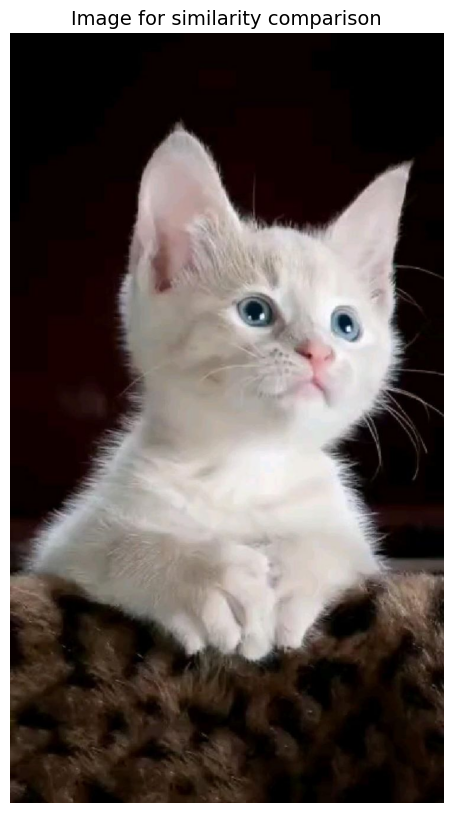

In [47]:
text_description = ["Two Bear in the Snow" ,
                    " A Cat on the Table " ,
                    " A picture of Big Ben at night" ,
                    " A Dog sleeping on the couch" ,
                    " Ice-creram cart on the road" ,
                    " colorful sky"]
display_image_and_compare("/content/image1.jpeg" , text_description)


 Best Match for image is  Ice-creram cart on the road with the score of 28.968273162841797


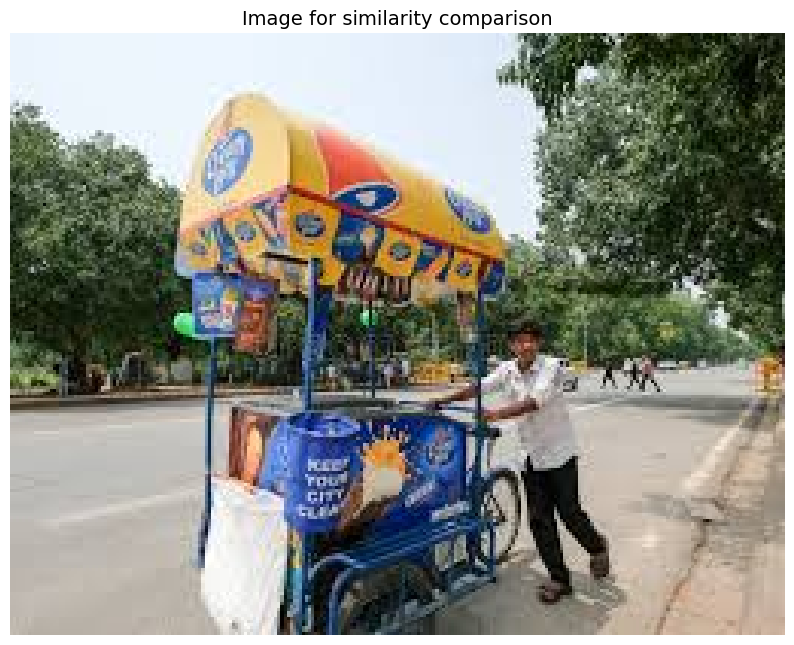

In [48]:
display_image_and_compare("/content/image4.jpeg" , text_description)


 Best Match for image is  A Cat on the Table  with the score of 30.353214263916016


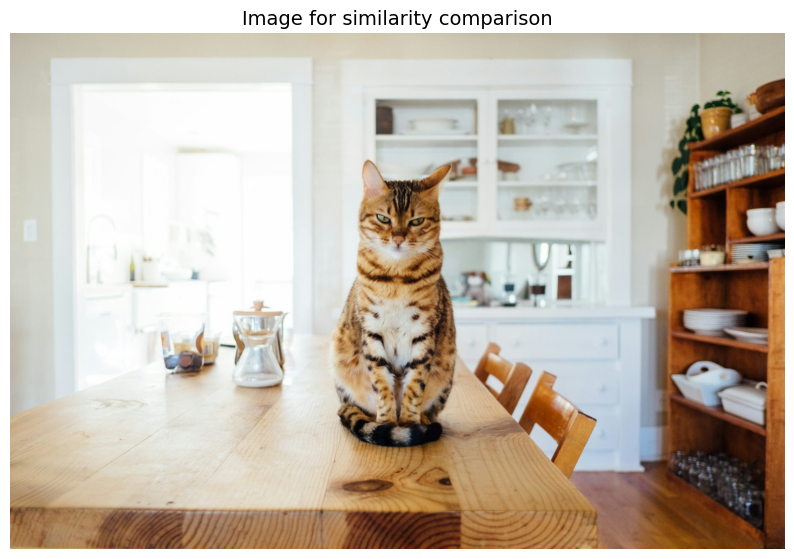

In [49]:
display_image_and_compare("/content/image2.jpeg" , text_description)


 Best Match for image is  colorful sky with the score of 29.763378143310547


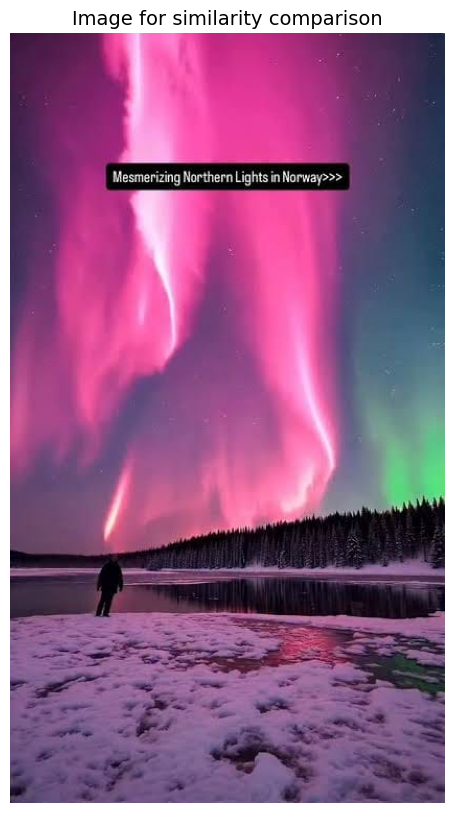

In [50]:
display_image_and_compare("/content/image6.jpeg" , text_description)


 Best Match for image is Two Bear in the Snow with the score of 23.743885040283203


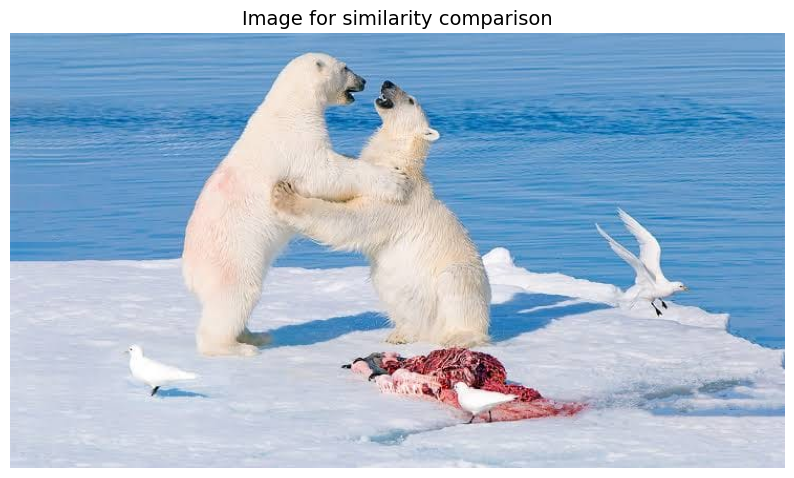

In [51]:
display_image_and_compare("/content/image5 (1).jpeg" , text_description)